In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [22]:
x= data[['AveRooms']].values
y=data['Price'].values


In [24]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
w = 0
b =0
learning_rate = 0.01
epochs = 1000
cost_history =[]
n = len(X_train_scaled)
for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
        cost_history.append(cost)
        print(f"Epoch {i}, Cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b

print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516
Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [25]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]
theta = np.linalg.inv(X_train_ne.T @X_train_ne) @X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

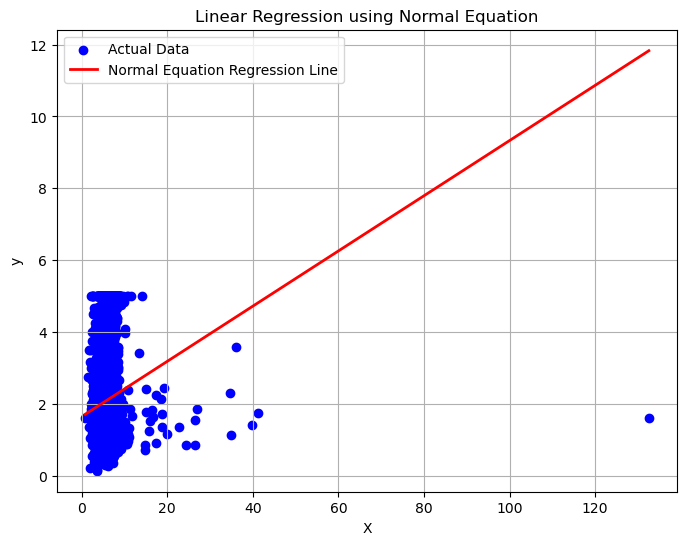

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

idx = np.argsort(X_test.flatten())

plt.plot(
    X_test.flatten()[idx],
    y_pred_ne[idx],
    color='red',
    linewidth=2,
    label='Normal Equation Regression Line'
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Normal Equation")
plt.legend()
plt.grid(True)
plt.show()



Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


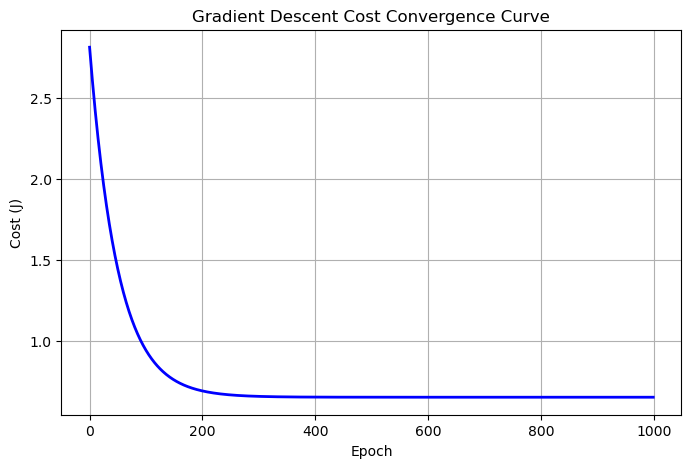

In [28]:
import numpy as np
import matplotlib.pyplot as plt

w = 0
b = 0

learning_rate = 0.01
epochs = 1000
n = len(X_train_scaled)

cost_history = []  

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(epochs), cost_history, color='blue', linewidth=2)
plt.title("Gradient Descent Cost Convergence Curve")
plt.xlabel("Epoch")
plt.ylabel("Cost (J)")
plt.grid(True)
plt.show()